En un interferómetro de Twyman-Green, el patrón de interferencia que se observa al calibrar un bloque patrón adherido a una platina de referencia se modela matemáticamente por la intensidad de dos ondas superpuestas:

$$I(x,y) = I_0(x,y) \left[ 1 + V \cos(\Delta \phi(x,y)) \right]$$

Donde:$I_0(x,y)$ es la intensidad de fondo (iluminación).$V$ es el contraste o visibilidad de las franjas.$\Delta \phi(x,y)$ es la diferencia de fase óptica. Para un bloque patrón de longitud $L$, la diferencia de fase respecto a la platina genera el salto de las franjas. La fase está dada por $\Delta \phi = \frac{4\pi}{\lambda} d(x,y)$, donde $d(x,y)$ incluye la inclinación de los espejos (las franjas que ves) y la altura del bloque.

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt 

In [10]:
def simular_twyman_green(resolucion=512, lambda_nm=632.8, longitud_bloque_nm=1000250.0, franjas_x=6.0, franjas_y=0.0, ruido=0.05):
    """
    Simula un patrón de interferencia de Twyman-Green para un bloque patrón.
    
    Parámetros:
    resolucion         : Tamaño de la imagen (N x N píxeles).
    lambda_nm          : Longitud de onda de la fuente láser en nanómetros.
    longitud_bloque_nm : Longitud del bloque patrón en nanómetros.
    franjas_x          : Densidad de franjas en el eje X (tilt).
    franjas_y          : Densidad de franjas en el eje Y (tilt).
    ruido              : Nivel de ruido gaussiano a añadir a la imagen.
    """
    
    # Crear malla espacial (coordenadas normalizadas de -1 a 1)
    x = np.linspace(-1, 1, resolucion)
    y = np.linspace(-1, 1, resolucion)
    X, Y = np.meshgrid(x, y)
    
    # Simular la altura del plano de la platina (tilt / inclinación)
    # franjas_x representa cuántas longitudes de onda de diferencia hay en el eje X
    altura_platina = (X * franjas_x + Y * franjas_y) * (lambda_nm / 2.0)
    
    # Simular la altura del bloque patrón
    altura_bloque = altura_platina + longitud_bloque_nm
    
    # Crear la máscara del bloque (un rectángulo en el centro)
    # Ajusta estos valores para cambiar el tamaño visual del bloque
    mascara_bloque = (np.abs(X) < 0.2) & (np.abs(Y) < 0.6)
    
    # Mapa de altura total combinando la platina y el bloque
    altura_total = np.where(mascara_bloque, altura_bloque, altura_platina)
    
    # Ecuación de interferencia fundamental
    # I = 1 + cos(4 * pi * h / lambda)
    fase = (4 * np.pi / lambda_nm) * altura_total
    
    # Intensidad normalizada de 0 a 1
    intensidad = 0.5 + 0.5 * np.cos(fase)
    
    # Añadir ruido instrumental simulado
    if ruido > 0:
        ruido_gaussiano = np.random.normal(0, ruido, intensidad.shape)
        intensidad = np.clip(intensidad + ruido_gaussiano, 0, 1)
        
    return intensidad

In [11]:
# Parámetros: Láser He-Ne rojo (632.8 nm), Bloque de longitud nominal + fracción
# Nota: La fracción de franja (f) depende del residuo de (2 * L / lambda)
longitud_onda = 632.9905846 # [nm]
longitud_real_bloque = 100000000.0 + 158.2 # 1 mm nominal + desfase para crear fracción

interferograma = simular_twyman_green(
    resolucion=600, 
    lambda_nm=longitud_onda, 
    longitud_bloque_nm=longitud_real_bloque, 
    franjas_x=0.0, 
    franjas_y=7.0, 
    ruido=0.08
)

In [12]:
longitud_real_bloque * 1e-6

100.0001582

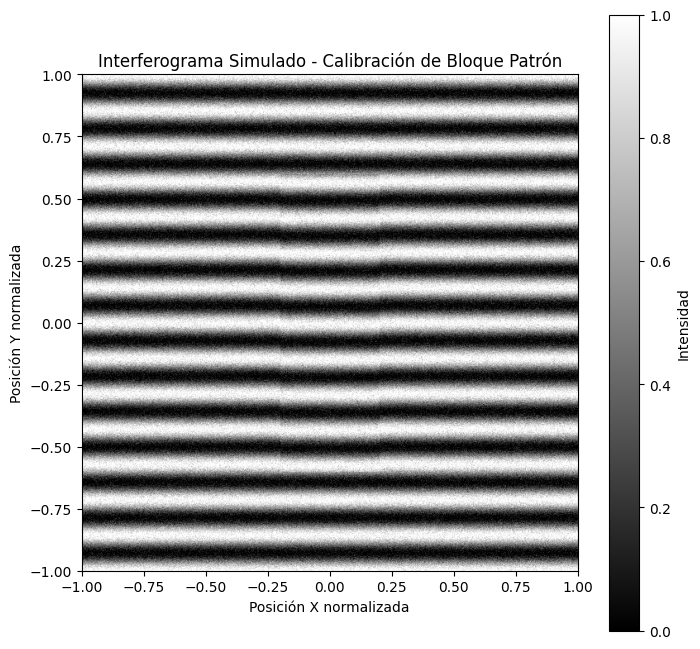

In [13]:
plt.figure(figsize=(8, 8))
plt.imshow(interferograma, cmap='gray', extent=[-1, 1, -1, 1])
plt.title('Interferograma Simulado - Calibración de Bloque Patrón')
plt.xlabel('Posición X normalizada')
plt.ylabel('Posición Y normalizada')
plt.colorbar(label='Intensidad')
plt.show()

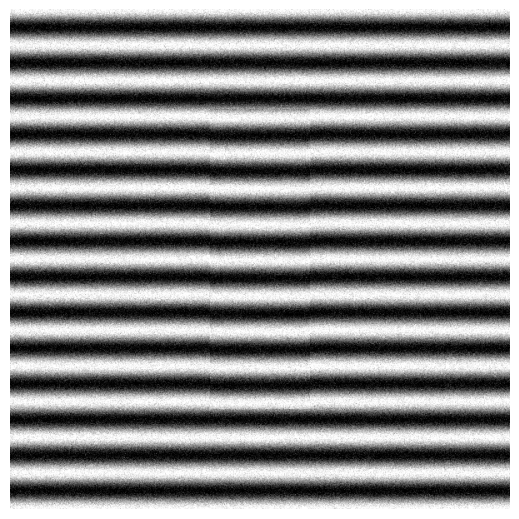

In [14]:
plt.figure(figsize=(5, 5))
plt.imshow(interferograma, cmap='gray')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

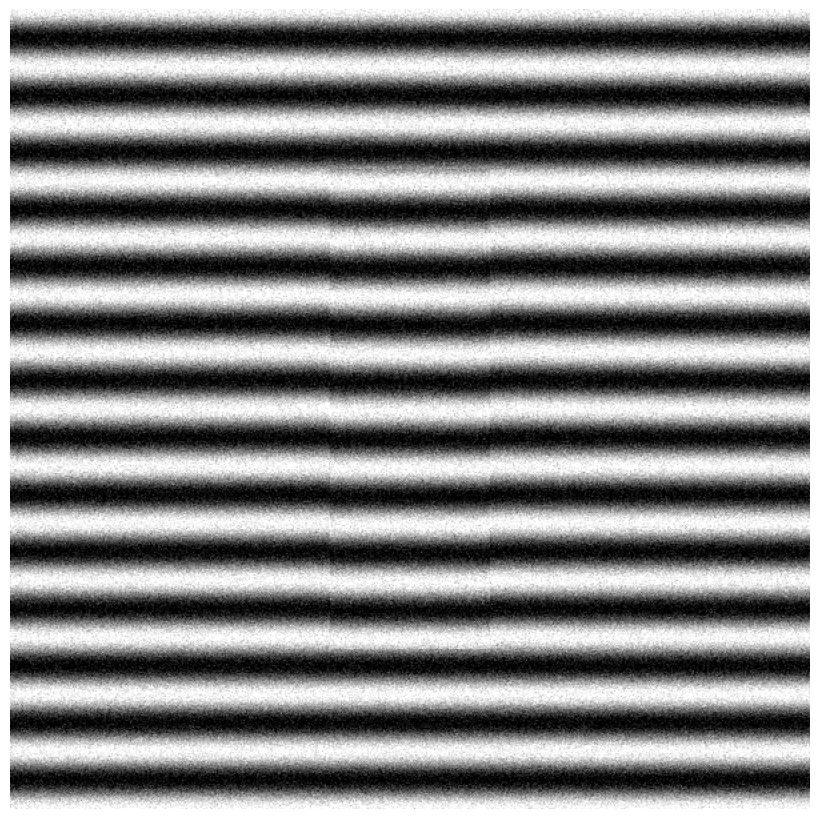

In [15]:
fig, ax = plt.subplots(figsize=(8, 8)) # Ajusta el tamaño de la figura (dpi alto si lo deseas)

# 2. Ajustar los submárgenes de la figura para que el contenido llene todo el espacio (de 0 a 1)
# Esto es crucial: dice "izquierda=0, derecha=1, abajo=0, arriba=1"
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

# 3. Mostrar la imagen en los ejes definidos
ax.imshow(interferograma, cmap='gray', aspect='auto') # 'aspect=auto' asegura que llene

# 4. Apagar los ejes (mantenemos esto, aplicado a los ejes específicos)
ax.axis('off')

nombre_archivo = f'block_{longitud_real_bloque * 1e-6}_mm-WL_{longitud_onda}-(simulated).png'
plt.savefig(nombre_archivo, bbox_inches='tight', pad_inches=0, dpi=300)

# Opcional: Mostrarla en pantalla
#plt.show()

In [16]:
print(os.getcwd())

c:\Users\jsrojas\Documents\Código\Exccess_fractions\notebooks
